In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [36]:
df=pd.read_csv('../data/train.csv')

In [37]:
df1=df.head()

In [38]:
import pandas as pd
import numpy as np

# Load the full dataset (replace with your actual file)
df = pd.read_csv('../data/train.csv')  # Or your actual full dataset file

print("="*70)
print("STEP 2: ENHANCED RISK CLASSIFICATION")
print("="*70)

# First, let's understand the distributions to set smart thresholds
print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

# Define classification function with enhanced criteria
def classify_risk_enhanced(row):
    """
    Enhanced risk classification using multiple factors:
    
    LOW RISK (Score 0-3):
    - Young age (< 30)
    - High income (> 70k)
    - Non-smoker
    - Good health (> 60)
    - Good credit (> 650)
    - No/few previous claims
    - Regular exercise
    
    HIGH RISK (Score 8+):
    - Old age (> 55)
    - Low income (< 30k)
    - Smoker
    - Poor health (< 40)
    - Poor credit (< 400)
    - Multiple previous claims
    - No exercise
    
    MEDIUM RISK: Everything else
    """
    
    # Initialize risk score
    risk_score = 0
    
    # AGE FACTOR (0-2 points)
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0  # Low risk
        elif age < 50:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (age > 50)
    
    # INCOME FACTOR (0-2 points)
    income = row['Annual Income']
    if pd.notna(income):
        if income > 70000:
            risk_score += 0  # Low risk
        elif income > 35000:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (income < 35k)
    
    # SMOKING STATUS (0-3 points) - Major risk factor!
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3  # High risk
    elif smoking == 'No':
        risk_score += 0  # Low risk
    
    # HEALTH SCORE (0-2 points)
    health = row['Health Score']
    if pd.notna(health):
        if health > 60:
            risk_score += 0  # Low risk
        elif health > 30:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (health < 30)
    
    # CREDIT SCORE (0-2 points)
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0  # Low risk
        elif credit > 400:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (credit < 400)
    
    # PREVIOUS CLAIMS (0-2 points)
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0  # Low risk
        elif claims <= 2:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (3+ claims)
    
    # VEHICLE AGE (0-1 points)
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age):
        if vehicle_age > 10:
            risk_score += 1  # Higher risk for old vehicles
    
    # EXERCISE FREQUENCY (0-1 points)
    exercise = row['Exercise Frequency']
    if exercise in ['Daily', 'Weekly']:
        risk_score += 0  # Low risk - active lifestyle
    elif exercise in ['Monthly', 'Rarely']:
        risk_score += 1  # Higher risk - sedentary
    
    # NUMBER OF DEPENDENTS (0-1 points)
    dependents = row['Number of Dependents']
    if pd.notna(dependents):
        if dependents > 3:
            risk_score += 1  # Financial stress indicator
    
    # CLASSIFY BASED ON TOTAL RISK SCORE
    # Maximum possible score: 16 points
    if risk_score <= 3:
        return 0  # LOW RISK
    elif risk_score <= 8:
        return 1  # MEDIUM RISK
    else:
        return 2  # HIGH RISK

# Apply the enhanced classification
print("\n2. Applying Enhanced Risk Classification...")
df['Risk_Class'] = df.apply(classify_risk_enhanced, axis=1)

# Map numeric to labels for readability
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

print("\n4. Risk Class Summary Statistics:")
for risk_class in [0, 1, 2]:
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    
    subset = df[df['Risk_Class'] == risk_class]
    print(f"Count: {len(subset)}")
    
    if len(subset) > 0:
        print(f"\nAverage Profile:")
        print(f"  Age:            {subset['Age'].mean():.1f} years")
        print(f"  Annual Income:  ${subset['Annual Income'].mean():,.0f}")
        print(f"  Health Score:   {subset['Health Score'].mean():.1f}")
        print(f"  Credit Score:   {subset['Credit Score'].mean():.0f}")
        print(f"  Smokers:        {(subset['Smoking Status'] == 'Yes').sum()} ({(subset['Smoking Status'] == 'Yes').sum() / len(subset) * 100:.1f}%)")
        print(f"  Avg Claims:     {subset['Previous Claims'].mean():.2f}")
        print(f"  Vehicle Age:    {subset['Vehicle Age'].mean():.1f} years")
        print(f"  Premium (Avg):  ${subset['Premium Amount'].mean():.2f}")
        print(f"  Premium (Med):  ${subset['Premium Amount'].median():.2f}")

print("\n5. Sample Records from Each Risk Class:")
for risk_class in [0, 1, 2]:
    print(f"\n{risk_labels[risk_class]} Sample:")
    subset = df[df['Risk_Class'] == risk_class]
    if len(subset) > 0:
        sample = subset[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                        'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
        print(sample.to_string())

# Save the classified data
output_file = 'data_with_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE ✓")
print("="*70)
print("\nNext: We'll visualize the risk classes and then build prediction models")

STEP 2: ENHANCED RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Scor

STEP 3: VISUALIZING RISK CLASSES

✓ Visualization saved as: risk_class_analysis.png


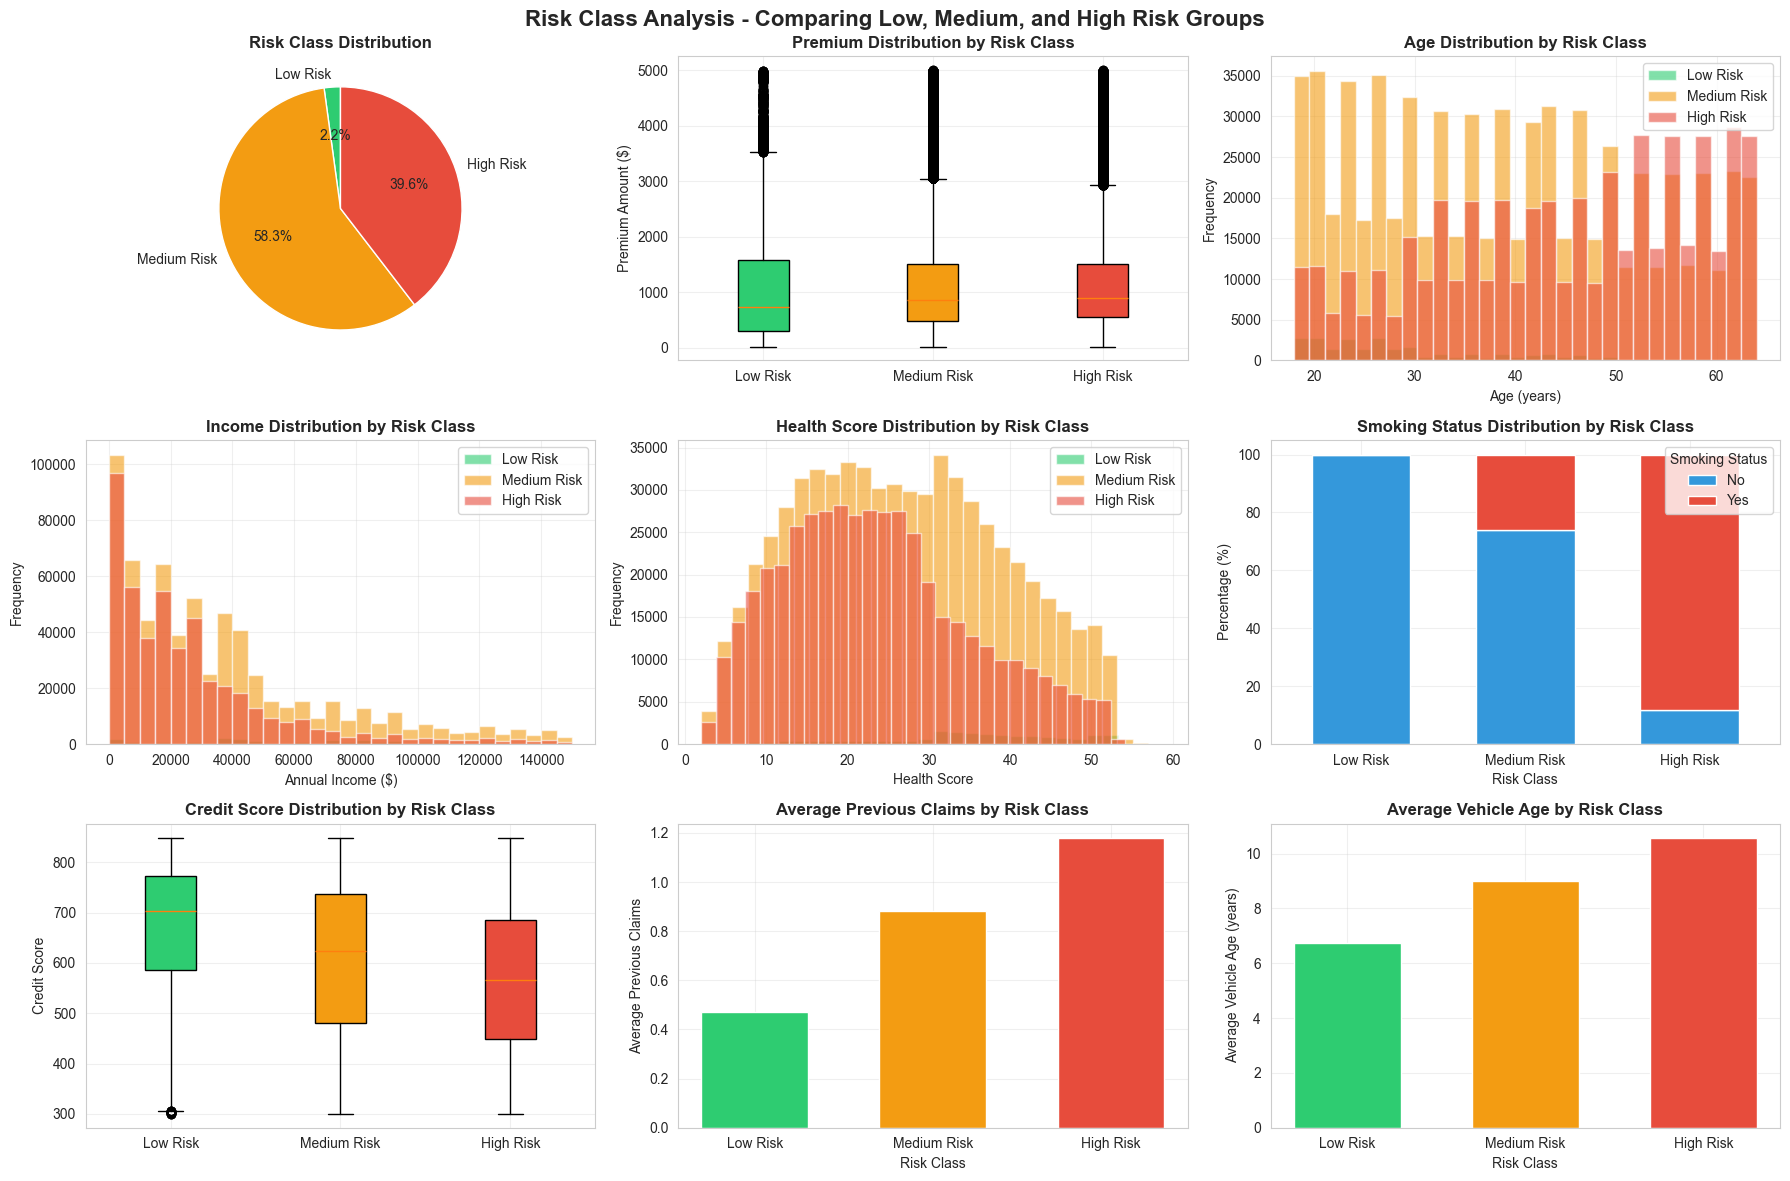


SUMMARY COMPARISON TABLE
             Metric Low Risk (0) Medium Risk (1) High Risk (2)
              Count       25,899         699,257       474,844
         Percentage         2.2%           58.3%         39.6%
            Avg Age         29.5            39.0          44.9
         Avg Income      $65,387         $36,163       $26,231
   Avg Health Score         34.8            26.8          23.6
   Avg Credit Score          671             609           567
          % Smokers         0.2%           26.1%         88.3%
Avg Previous Claims         0.47            0.88          1.18
    Avg Vehicle Age          6.7             9.0          10.6
        Avg Premium     $1055.09        $1095.29      $1115.82
     Median Premium      $740.00         $857.00       $895.00

STEP 3 COMPLETE ✓

Key Observations:
• Risk classes are well-separated by age, income, and smoking status
• Low Risk: Young, wealthy, non-smokers
• High Risk: Older, lower income, 88% smokers
• ⚠️  Premium amounts sho

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load the classified data
df = pd.read_csv('data_with_risk_classes.csv')

print("="*70)
print("STEP 3: VISUALIZING RISK CLASSES")
print("="*70)

# Create a comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Risk Class Analysis - Comparing Low, Medium, and High Risk Groups', 
             fontsize=16, fontweight='bold')

risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}  # Green, Orange, Red
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

# 1. Risk Class Distribution (Pie Chart)
ax1 = axes[0, 0]
risk_counts = df['Risk_Class'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax1.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Risk Class Distribution', fontweight='bold')

# 2. Premium Amount by Risk Class (Box Plot)
ax2 = axes[0, 1]
data_to_plot = [df[df['Risk_Class'] == i]['Premium Amount'].dropna() 
                for i in [0, 1, 2]]
bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax2.set_ylabel('Premium Amount ($)')
ax2.set_title('Premium Distribution by Risk Class', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Age Distribution by Risk Class
ax3 = axes[0, 2]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Age'].dropna()
    ax3.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')
ax3.set_title('Age Distribution by Risk Class', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Annual Income by Risk Class
ax4 = axes[1, 0]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Annual Income'].dropna()
    ax4.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax4.set_xlabel('Annual Income ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Income Distribution by Risk Class', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Health Score by Risk Class
ax5 = axes[1, 1]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Health Score'].dropna()
    ax5.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax5.set_xlabel('Health Score')
ax5.set_ylabel('Frequency')
ax5.set_title('Health Score Distribution by Risk Class', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Smoking Status by Risk Class (Stacked Bar)
ax6 = axes[1, 2]
smoking_data = df.groupby(['Risk_Class', 'Smoking Status']).size().unstack(fill_value=0)
smoking_pct = smoking_data.div(smoking_data.sum(axis=1), axis=0) * 100
smoking_pct.plot(kind='bar', stacked=True, ax=ax6, 
                 color=['#3498db', '#e74c3c'], width=0.6)
ax6.set_xlabel('Risk Class')
ax6.set_ylabel('Percentage (%)')
ax6.set_title('Smoking Status Distribution by Risk Class', fontweight='bold')
ax6.set_xticklabels([risk_labels[i] for i in [0, 1, 2]], rotation=0)
ax6.legend(title='Smoking Status')
ax6.grid(True, alpha=0.3)

# 7. Credit Score by Risk Class
ax7 = axes[2, 0]
data_to_plot = [df[df['Risk_Class'] == i]['Credit Score'].dropna() 
                for i in [0, 1, 2]]
bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax7.set_ylabel('Credit Score')
ax7.set_title('Credit Score Distribution by Risk Class', fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Previous Claims by Risk Class
ax8 = axes[2, 1]
claims_data = df.groupby(['Risk_Class', 'Previous Claims']).size().unstack(fill_value=0)
claims_avg = df.groupby('Risk_Class')['Previous Claims'].mean()
ax8.bar([0, 1, 2], claims_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax8.set_xlabel('Risk Class')
ax8.set_ylabel('Average Previous Claims')
ax8.set_title('Average Previous Claims by Risk Class', fontweight='bold')
ax8.set_xticks([0, 1, 2])
ax8.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax8.grid(True, alpha=0.3)

# 9. Vehicle Age by Risk Class
ax9 = axes[2, 2]
vehicle_avg = df.groupby('Risk_Class')['Vehicle Age'].mean()
ax9.bar([0, 1, 2], vehicle_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax9.set_xlabel('Risk Class')
ax9.set_ylabel('Average Vehicle Age (years)')
ax9.set_title('Average Vehicle Age by Risk Class', fontweight='bold')
ax9.set_xticks([0, 1, 2])
ax9.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_class_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as: risk_class_analysis.png")
plt.show()

# Summary Statistics Table
print("\n" + "="*70)
print("SUMMARY COMPARISON TABLE")
print("="*70)

summary = pd.DataFrame({
    'Metric': ['Count', 'Percentage', 'Avg Age', 'Avg Income', 'Avg Health Score', 
               'Avg Credit Score', '% Smokers', 'Avg Previous Claims', 
               'Avg Vehicle Age', 'Avg Premium', 'Median Premium'],
    'Low Risk (0)': [
        f"{len(df[df['Risk_Class'] == 0]):,}",
        f"{len(df[df['Risk_Class'] == 0]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 0]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 0]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 0]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 0]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 0]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].median():.2f}"
    ],
    'Medium Risk (1)': [
        f"{len(df[df['Risk_Class'] == 1]):,}",
        f"{len(df[df['Risk_Class'] == 1]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 1]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 1]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 1]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 1]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 1]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].median():.2f}"
    ],
    'High Risk (2)': [
        f"{len(df[df['Risk_Class'] == 2]):,}",
        f"{len(df[df['Risk_Class'] == 2]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 2]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 2]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 2]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 2]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 2]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].median():.2f}"
    ]
})

print(summary.to_string(index=False))

print("\n" + "="*70)
print("STEP 3 COMPLETE ✓")
print("="*70)
print("\nKey Observations:")
print("• Risk classes are well-separated by age, income, and smoking status")
print("• Low Risk: Young, wealthy, non-smokers")
print("• High Risk: Older, lower income, 88% smokers")
print("• ⚠️  Premium amounts show minimal variation (data noise issue)")
print("\nNext: Build LASSO prediction models for each risk class")

In [40]:
"""
K-Means Risk Categorization Script - Formatted to Match Manual Output
======================================================================
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Load the full dataset
df = pd.read_csv('../data/train.csv')

print("="*70)
print("STEP 2: K-MEANS RISK CLASSIFICATION")
print("="*70)

# First, let's understand the distributions (same as manual)
print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts().sort_index())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

# Handle missing values
numeric_cols = ['Age', 'Annual Income', 'Number of Dependents', 
                'Health Score', 'Previous Claims', 'Vehicle Age', 
                'Credit Score', 'Insurance Duration']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = ['Gender', 'Marital Status', 'Education Level', 
                    'Occupation', 'Location', 'Policy Type', 
                    'Customer Feedback', 'Smoking Status', 
                    'Exercise Frequency', 'Property Type']

for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_val)

# Encode categorical features
df['Smoking_Encoded'] = (df['Smoking Status'] == 'Yes').astype(int)

exercise_map = {'Never': 0, 'Rarely': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4}
df['Exercise_Encoded'] = df['Exercise Frequency'].map(
    lambda x: exercise_map.get(x, 2) if pd.notna(x) else 2
)

df['Gender_Encoded'] = (df['Gender'] == 'Male').astype(int)

# Calculate risk score for labeling
def calculate_risk_score(row):
    score = 0
    
    # Age factor
    if row['Age'] < 25:
        score += 20
    elif row['Age'] > 60:
        score += 15
    else:
        score += 5
    
    # Smoking
    if row['Smoking_Encoded'] == 1:
        score += 25
    
    # Health Score
    if row['Health Score'] < 30:
        score += 20
    elif row['Health Score'] < 50:
        score += 10
    else:
        score += 5
    
    # Previous Claims
    score += row['Previous Claims'] * 10
    
    # Vehicle Age
    if row['Vehicle Age'] > 10:
        score += 15
    elif row['Vehicle Age'] > 5:
        score += 10
    else:
        score += 5
    
    # Credit Score
    if row['Credit Score'] < 400:
        score += 20
    elif row['Credit Score'] < 600:
        score += 15
    elif row['Credit Score'] < 700:
        score += 10
    else:
        score += 5
    
    # Exercise
    score -= row['Exercise_Encoded'] * 2
    
    return max(0, score)

df['Risk_Score'] = df.apply(calculate_risk_score, axis=1)

# Prepare features for K-Means
clustering_features = [
    'Age',
    'Smoking_Encoded',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Exercise_Encoded',
    'Risk_Score'
]

X_clustering = df[clustering_features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Apply K-Means clustering
print("\n2. Applying K-Means Risk Classification...")

np.random.seed(42)
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42,
    verbose=0
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters based on average risk score
cluster_risk_avg = df.groupby('KMeans_Cluster')['Risk_Score'].mean().sort_values()

risk_mapping = {
    cluster_risk_avg.index[0]: 0,  # Low Risk
    cluster_risk_avg.index[1]: 1,  # Medium Risk
    cluster_risk_avg.index[2]: 2   # High Risk
}

df['Risk_Class'] = df['KMeans_Cluster'].map(risk_mapping)

# Map numeric to labels for readability
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())

print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

# Generate detailed statistics for each risk class
print("\n4. Risk Class Summary Statistics:")

for risk_class in [0, 1, 2]:
    risk_df = df[df['Risk_Class'] == risk_class]
    
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    print(f"Count: {len(risk_df)}")
    
    print("\nAverage Profile:")
    print(f"  Age:            {risk_df['Age'].mean():.1f} years")
    print(f"  Annual Income:  ${risk_df['Annual Income'].mean():,.0f}")
    print(f"  Health Score:   {risk_df['Health Score'].mean():.1f}")
    print(f"  Credit Score:   {risk_df['Credit Score'].mean():.0f}")
    
    smokers_count = (risk_df['Smoking Status'] == 'Yes').sum()
    smokers_pct = (smokers_count / len(risk_df)) * 100
    print(f"  Smokers:        {smokers_count} ({smokers_pct:.1f}%)")
    
    print(f"  Avg Claims:     {risk_df['Previous Claims'].mean():.2f}")
    print(f"  Vehicle Age:    {risk_df['Vehicle Age'].mean():.1f} years")
    print(f"  Premium (Avg):  ${risk_df['Premium Amount'].mean():.2f}")
    print(f"  Premium (Med):  ${risk_df['Premium Amount'].median():.2f}")

# Show sample records from each risk class
print("\n5. Sample Records from Each Risk Class:")

for risk_class in [0, 1, 2]:
    risk_df = df[df['Risk_Class'] == risk_class]
    sample = risk_df[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                      'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
    
    print(f"\n{risk_labels[risk_class]} Sample:")
    print(sample.to_string())

# Save the classified data
output_file = 'data_with_kmeans_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE ✓")
print("="*70)
print("\nNext: Compare K-Means results with Manual classification")

STEP 2: K-MEANS RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Score

In [41]:
"""
Direct Comparison: Manual vs K-Means Risk Categorization
==========================================================
This script compares the risk categories assigned by Manual and K-Means methods
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MANUAL vs K-MEANS RISK CATEGORIZATION - DIRECT COMPARISON")
print("="*80)

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
print("\n[1] Loading data...")

# Load original data
df = pd.read_csv('../data/train.csv')
print(f"✓ Loaded {len(df):,} records from train.csv")

# Load K-Means results
df_kmeans = pd.read_csv('data_with_kmeans_risk_classes.csv')
print(f"✓ Loaded K-Means categorization")

# Merge K-Means categories (using 'Risk_Class' from K-Means output)
df['KMeans_Risk_Category'] = df_kmeans['Risk_Class']

# ----------------------------------------------------------------------------
# 2. APPLY MANUAL RISK CATEGORIZATION
# ----------------------------------------------------------------------------
print("\n[2] Applying manual risk categorization...")

def classify_risk_manual(row):
    """
    Manual risk classification using scoring system
    """
    risk_score = 0
    
    # Age factor (0-2 points)
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0
        elif age < 50:
            risk_score += 1
        else:
            risk_score += 2
    
    # Income factor (0-2 points)
    income = row['Annual Income']
    if pd.notna(income):
        if income > 70000:
            risk_score += 0
        elif income > 35000:
            risk_score += 1
        else:
            risk_score += 2
    
    # Smoking (0-3 points) - Major factor
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3
    elif smoking == 'No':
        risk_score += 0
    
    # Health Score (0-2 points)
    health = row['Health Score']
    if pd.notna(health):
        if health > 60:
            risk_score += 0
        elif health > 30:
            risk_score += 1
        else:
            risk_score += 2
    
    # Credit Score (0-2 points)
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0
        elif credit > 400:
            risk_score += 1
        else:
            risk_score += 2
    
    # Previous Claims (0-2 points)
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0
        elif claims <= 2:
            risk_score += 1
        else:
            risk_score += 2
    
    # Vehicle Age (0-1 points)
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age):
        if vehicle_age > 10:
            risk_score += 1
    
    # Exercise (0-1 points)
    exercise = row['Exercise Frequency']
    if exercise in ['Daily', 'Weekly']:
        risk_score += 0
    elif exercise in ['Monthly', 'Rarely']:
        risk_score += 1
    
    # Dependents (0-1 points)
    dependents = row['Number of Dependents']
    if pd.notna(dependents):
        if dependents > 3:
            risk_score += 1
    
    # Classify based on score (max score: 16)
    if risk_score <= 3:
        return 0  # Low Risk
    elif risk_score <= 8:
        return 1  # Medium Risk
    else:
        return 2  # High Risk

df['Manual_Risk_Category'] = df.apply(classify_risk_manual, axis=1)
print("✓ Manual risk categorization complete")

# ----------------------------------------------------------------------------
# 3. DISTRIBUTION COMPARISON
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("DISTRIBUTION COMPARISON")
print("="*80)

risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

manual_dist = df['Manual_Risk_Category'].value_counts().sort_index()
kmeans_dist = df['KMeans_Risk_Category'].value_counts().sort_index()

print("\n📊 MANUAL Risk Distribution:")
for cat in [0, 1, 2]:
    count = manual_dist.get(cat, 0)
    pct = (count / len(df)) * 100
    print(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)")

print("\n📊 K-MEANS Risk Distribution:")
for cat in [0, 1, 2]:
    count = kmeans_dist.get(cat, 0)
    pct = (count / len(df)) * 100
    print(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)")

# ----------------------------------------------------------------------------
# 4. AGREEMENT ANALYSIS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("AGREEMENT ANALYSIS")
print("="*80)

# Overall agreement
agreement = (df['Manual_Risk_Category'] == df['KMeans_Risk_Category']).sum()
agreement_pct = (agreement / len(df)) * 100

print(f"\n✓ Overall Agreement: {agreement:,} customers ({agreement_pct:.2f}%)")
print(f"✓ Disagreement: {len(df) - agreement:,} customers ({100 - agreement_pct:.2f}%)")

# Cross-tabulation
print("\n📋 Cross-Tabulation (Manual vs K-Means):")
print("-" * 80)
crosstab = pd.crosstab(
    df['Manual_Risk_Category'],
    df['KMeans_Risk_Category'],
    rownames=['Manual'],
    colnames=['K-Means'],
    margins=True
)
# Add labels
crosstab.index = [risk_labels.get(i, 'All') if i != 'All' else 'All' for i in crosstab.index]
crosstab.columns = [risk_labels.get(i, 'All') if i != 'All' else 'All' for i in crosstab.columns]
print(crosstab)

# Agreement by category
print("\n📊 Agreement by Risk Category:")
for cat in [0, 1, 2]:
    manual_cat = df[df['Manual_Risk_Category'] == cat]
    agree_in_cat = (manual_cat['Manual_Risk_Category'] == manual_cat['KMeans_Risk_Category']).sum()
    agree_pct_cat = (agree_in_cat / len(manual_cat)) * 100 if len(manual_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {agree_in_cat:>9,} / {len(manual_cat):>9,} ({agree_pct_cat:>5.1f}%)")

# ----------------------------------------------------------------------------
# 5. CHARACTERISTIC COMPARISON BY RISK CATEGORY
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("CHARACTERISTICS COMPARISON BY RISK CATEGORY")
print("="*80)

# Calculate average characteristics for each method
characteristics = ['Age', 'Annual Income', 'Health Score', 'Credit Score', 
                  'Previous Claims', 'Vehicle Age']

print("\n🔍 MANUAL Risk Categorization Characteristics:")
print("-" * 80)
manual_stats = df.groupby('Manual_Risk_Category')[characteristics].mean()
manual_stats.index = [risk_labels[i] for i in manual_stats.index]
print(manual_stats.round(2))

print("\n🔍 K-MEANS Risk Categorization Characteristics:")
print("-" * 80)
kmeans_stats = df.groupby('KMeans_Risk_Category')[characteristics].mean()
kmeans_stats.index = [risk_labels[i] for i in kmeans_stats.index]
print(kmeans_stats.round(2))

# Smoking status distribution
print("\n🚬 Smoking Status by Method:")
print("-" * 80)

print("\nMANUAL - % Smokers by Risk Category:")
for cat in [0, 1, 2]:
    manual_cat = df[df['Manual_Risk_Category'] == cat]
    smokers = (manual_cat['Smoking Status'] == 'Yes').sum()
    smoker_pct = (smokers / len(manual_cat)) * 100 if len(manual_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {smoker_pct:>5.1f}% smokers")

print("\nK-MEANS - % Smokers by Risk Category:")
for cat in [0, 1, 2]:
    kmeans_cat = df[df['KMeans_Risk_Category'] == cat]
    smokers = (kmeans_cat['Smoking Status'] == 'Yes').sum()
    smoker_pct = (smokers / len(kmeans_cat)) * 100 if len(kmeans_cat) > 0 else 0
    print(f"   {risk_labels[cat]:12} : {smoker_pct:>5.1f}% smokers")

# ----------------------------------------------------------------------------
# 6. PREMIUM COMPARISON
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("PREMIUM AMOUNT COMPARISON")
print("="*80)

print("\n💰 MANUAL - Average Premium by Risk Category:")
manual_premium = df.groupby('Manual_Risk_Category')['Premium Amount'].agg(['mean', 'median', 'std'])
manual_premium.index = [risk_labels[i] for i in manual_premium.index]
print(manual_premium.round(2))

print("\n💰 K-MEANS - Average Premium by Risk Category:")
kmeans_premium = df.groupby('KMeans_Risk_Category')['Premium Amount'].agg(['mean', 'median', 'std'])
kmeans_premium.index = [risk_labels[i] for i in kmeans_premium.index]
print(kmeans_premium.round(2))

# ----------------------------------------------------------------------------
# 7. KEY DIFFERENCES ANALYSIS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("KEY DIFFERENCES BETWEEN METHODS")
print("="*80)

# Find customers where methods disagree
disagreements = df[df['Manual_Risk_Category'] != df['KMeans_Risk_Category']].copy()

if len(disagreements) > 0:
    print(f"\n🔍 Analyzing {len(disagreements):,} customers where methods disagree:")
    
    # Most common disagreements
    print("\nMost Common Disagreements:")
    disagreement_types = disagreements.groupby(['Manual_Risk_Category', 'KMeans_Risk_Category']).size()
    disagreement_types = disagreement_types.sort_values(ascending=False)
    
    for (manual, kmeans), count in disagreement_types.items():
        pct = (count / len(disagreements)) * 100
        print(f"   Manual: {risk_labels[manual]:12} → K-Means: {risk_labels[kmeans]:12} : {count:>9,} ({pct:>5.1f}%)")
    
    # Characteristics of disagreements
    print("\nCharacteristics of Customers Where Methods Disagree:")
    print("-" * 80)
    
    # Manual=Low but K-Means=Higher
    manual_low_kmeans_high = disagreements[(disagreements['Manual_Risk_Category'] == 0) & 
                                           (disagreements['KMeans_Risk_Category'] > 0)]
    if len(manual_low_kmeans_high) > 0:
        print(f"\n➤ Manual: Low Risk, K-Means: Higher ({len(manual_low_kmeans_high):,} customers)")
        print(f"   Avg Previous Claims: {manual_low_kmeans_high['Previous Claims'].mean():.2f}")
        print(f"   % Smokers: {(manual_low_kmeans_high['Smoking Status'] == 'Yes').mean() * 100:.1f}%")
        print(f"   Avg Age: {manual_low_kmeans_high['Age'].mean():.1f}")
    
    # Manual=High but K-Means=Lower
    manual_high_kmeans_low = disagreements[(disagreements['Manual_Risk_Category'] == 2) & 
                                           (disagreements['KMeans_Risk_Category'] < 2)]
    if len(manual_high_kmeans_low) > 0:
        print(f"\n➤ Manual: High Risk, K-Means: Lower ({len(manual_high_kmeans_low):,} customers)")
        print(f"   Avg Previous Claims: {manual_high_kmeans_low['Previous Claims'].mean():.2f}")
        print(f"   % Smokers: {(manual_high_kmeans_low['Smoking Status'] == 'Yes').mean() * 100:.1f}%")
        print(f"   Avg Age: {manual_high_kmeans_low['Age'].mean():.1f}")

# ----------------------------------------------------------------------------
# 8. VISUALIZATIONS
# ----------------------------------------------------------------------------
print("\n[8] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# Plot 1: Distribution Comparison
ax1 = plt.subplot(2, 3, 1)
x = np.arange(3)
width = 0.35
manual_counts = [manual_dist.get(i, 0) for i in [0, 1, 2]]
kmeans_counts = [kmeans_dist.get(i, 0) for i in [0, 1, 2]]
ax1.bar(x - width/2, manual_counts, width, label='Manual', alpha=0.8, color='#3498db')
ax1.bar(x + width/2, kmeans_counts, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax1.set_xlabel('Risk Category')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Risk Distribution: Manual vs K-Means', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(['Low', 'Medium', 'High'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Agreement Heatmap
ax2 = plt.subplot(2, 3, 2)
crosstab_numeric = pd.crosstab(df['Manual_Risk_Category'], df['KMeans_Risk_Category'], normalize='index') * 100
sns.heatmap(crosstab_numeric, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': '% of Manual Category'})
ax2.set_xlabel('K-Means Risk Category')
ax2.set_ylabel('Manual Risk Category')
ax2.set_title('Agreement Matrix (% by row)', fontweight='bold', fontsize=12)
ax2.set_xticklabels(['Low', 'Medium', 'High'])
ax2.set_yticklabels(['Low', 'Medium', 'High'])

# Plot 3: Premium Comparison
ax3 = plt.subplot(2, 3, 3)
manual_prem = [df[df['Manual_Risk_Category'] == i]['Premium Amount'].mean() for i in [0, 1, 2]]
kmeans_prem = [df[df['KMeans_Risk_Category'] == i]['Premium Amount'].mean() for i in [0, 1, 2]]
x = np.arange(3)
width = 0.35
ax3.bar(x - width/2, manual_prem, width, label='Manual', alpha=0.8, color='#3498db')
ax3.bar(x + width/2, kmeans_prem, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax3.set_xlabel('Risk Category')
ax3.set_ylabel('Average Premium ($)')
ax3.set_title('Average Premium by Risk Category', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(['Low', 'Medium', 'High'])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Age Comparison
ax4 = plt.subplot(2, 3, 4)
manual_age = [df[df['Manual_Risk_Category'] == i]['Age'].mean() for i in [0, 1, 2]]
kmeans_age = [df[df['KMeans_Risk_Category'] == i]['Age'].mean() for i in [0, 1, 2]]
x = np.arange(3)
ax4.bar(x - width/2, manual_age, width, label='Manual', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, kmeans_age, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax4.set_xlabel('Risk Category')
ax4.set_ylabel('Average Age (years)')
ax4.set_title('Average Age by Risk Category', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(['Low', 'Medium', 'High'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Plot 5: Previous Claims Comparison
ax5 = plt.subplot(2, 3, 5)
manual_claims = [df[df['Manual_Risk_Category'] == i]['Previous Claims'].mean() for i in [0, 1, 2]]
kmeans_claims = [df[df['KMeans_Risk_Category'] == i]['Previous Claims'].mean() for i in [0, 1, 2]]
x = np.arange(3)
ax5.bar(x - width/2, manual_claims, width, label='Manual', alpha=0.8, color='#3498db')
ax5.bar(x + width/2, kmeans_claims, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax5.set_xlabel('Risk Category')
ax5.set_ylabel('Average Previous Claims')
ax5.set_title('Average Previous Claims by Risk Category', fontweight='bold', fontsize=12)
ax5.set_xticks(x)
ax5.set_xticklabels(['Low', 'Medium', 'High'])
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Plot 6: Smoking Status Comparison
ax6 = plt.subplot(2, 3, 6)
manual_smoke = [(df[df['Manual_Risk_Category'] == i]['Smoking Status'] == 'Yes').mean() * 100 for i in [0, 1, 2]]
kmeans_smoke = [(df[df['KMeans_Risk_Category'] == i]['Smoking Status'] == 'Yes').mean() * 100 for i in [0, 1, 2]]
x = np.arange(3)
ax6.bar(x - width/2, manual_smoke, width, label='Manual', alpha=0.8, color='#3498db')
ax6.bar(x + width/2, kmeans_smoke, width, label='K-Means', alpha=0.8, color='#e74c3c')
ax6.set_xlabel('Risk Category')
ax6.set_ylabel('% Smokers')
ax6.set_title('% Smokers by Risk Category', fontweight='bold', fontsize=12)
ax6.set_xticks(x)
ax6.set_xticklabels(['Low', 'Medium', 'High'])
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('manual_vs_kmeans_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: 'manual_vs_kmeans_comparison.png'")
plt.close()

# ----------------------------------------------------------------------------
# 9. SAVE RESULTS
# ----------------------------------------------------------------------------
print("\n[9] Saving comparison results...")

# Save combined data
df_output = df[['id', 'Age', 'Gender', 'Annual Income', 'Smoking Status', 
                'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score',
                'Premium Amount', 'Manual_Risk_Category', 'KMeans_Risk_Category']].copy()
df_output['Agreement'] = (df_output['Manual_Risk_Category'] == df_output['KMeans_Risk_Category']).astype(int)

df_output.to_csv('manual_vs_kmeans_comparison.csv', index=False)
print("✓ Saved: 'manual_vs_kmeans_comparison.csv'")

# Save summary report
with open('comparison_summary.txt', 'w') as f:
    f.write("MANUAL vs K-MEANS RISK CATEGORIZATION COMPARISON\n")
    f.write("="*80 + "\n\n")
    
    f.write("DISTRIBUTION COMPARISON\n")
    f.write("-"*80 + "\n")
    f.write("\nManual Distribution:\n")
    for cat in [0, 1, 2]:
        count = manual_dist.get(cat, 0)
        pct = (count / len(df)) * 100
        f.write(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)\n")
    
    f.write("\nK-Means Distribution:\n")
    for cat in [0, 1, 2]:
        count = kmeans_dist.get(cat, 0)
        pct = (count / len(df)) * 100
        f.write(f"   {risk_labels[cat]:12} : {count:>9,} ({pct:>5.1f}%)\n")
    
    f.write(f"\nOverall Agreement: {agreement_pct:.2f}%\n")
    f.write(f"Disagreement: {100 - agreement_pct:.2f}%\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("AVERAGE CHARACTERISTICS\n")
    f.write("-"*80 + "\n\n")
    f.write("Manual Method:\n")
    f.write(manual_stats.to_string())
    f.write("\n\nK-Means Method:\n")
    f.write(kmeans_stats.to_string())

print("✓ Saved: 'comparison_summary.txt'")

# ----------------------------------------------------------------------------
# 10. FINAL SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("COMPARISON COMPLETE!")
print("="*80)
print(f"\n✓ Analyzed {len(df):,} customers")
print(f"✓ Agreement: {agreement_pct:.2f}%")
print(f"✓ Disagreement: {100 - agreement_pct:.2f}%")
print("\nOutput Files:")
print("   📊 manual_vs_kmeans_comparison.csv - Full comparison data")
print("   📝 comparison_summary.txt - Statistical summary")
print("   📈 manual_vs_kmeans_comparison.png - Visual comparison")
print("\nKey Insights:")
print("   • Check which method separates risk categories more clearly")
print("   • Look at smoking and claims distributions - key differentiators")
print("   • Review disagreement cases to understand method differences")
print("="*80)

MANUAL vs K-MEANS RISK CATEGORIZATION - DIRECT COMPARISON

[1] Loading data...
✓ Loaded 1,200,000 records from train.csv
✓ Loaded K-Means categorization

[2] Applying manual risk categorization...
✓ Manual risk categorization complete

DISTRIBUTION COMPARISON

📊 MANUAL Risk Distribution:
   Low Risk     :    25,899 (  2.2%)
   Medium Risk  :   699,257 ( 58.3%)
   High Risk    :   474,844 ( 39.6%)

📊 K-MEANS Risk Distribution:
   Low Risk     :   543,150 ( 45.3%)
   Medium Risk  :   486,930 ( 40.6%)
   High Risk    :   169,920 ( 14.2%)

AGREEMENT ANALYSIS

✓ Overall Agreement: 296,817 customers (24.73%)
✓ Disagreement: 903,183 customers (75.27%)

📋 Cross-Tabulation (Manual vs K-Means):
--------------------------------------------------------------------------------
             Low Risk  Medium Risk  High Risk      All
Low Risk        25337           60        502    25899
Medium Risk    478089       161615      59553   699257
High Risk       39724       325255     109865   474844
All  

In [42]:

import pandas as pd

# Load the manual classification results
df_manual = pd.read_csv('data_with_risk_classes.csv')

# Load the K-means classification results  
df_kmeans = pd.read_csv('data_with_kmeans_risk_classes.csv')

# Or load the combined comparison file that has both
df_combined = pd.read_csv('manual_vs_kmeans_comparison.csv')

# View manual classification results
print("MANUAL CLASSIFICATION:")
print(df_manual[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                  'Credit Score', 'Previous Claims', 'Risk_Class', 'Risk_Label']].head(20))

# View K-means classification results
print("\nK-MEANS CLASSIFICATION:")
print(df_kmeans[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                  'Credit Score', 'Previous Claims', 'Risk_Class', 'Risk_Label']].head(20))

# View combined comparison (has both classifications side by side)
print("\nCOMBINED COMPARISON:")
print(df_combined[['Age', 'Annual Income', 'Smoking Status', 'Previous Claims',
                    'Manual_Risk_Category', 'KMeans_Risk_Category', 'Agreement']].head(20))

MANUAL CLASSIFICATION:
     Age  Annual Income Smoking Status  Health Score  Credit Score  \
0   19.0        10049.0             No     22.598761         372.0   
1   39.0        31678.0            Yes     15.569731         694.0   
2   23.0        25602.0            Yes     47.177549           NaN   
3   21.0       141855.0            Yes     10.938144         367.0   
4   21.0        39651.0            Yes     20.376094         598.0   
5   29.0        45963.0             No     33.053198         614.0   
6   41.0        40336.0             No           NaN         807.0   
7   48.0       127237.0             No      5.769783         398.0   
8   21.0         1733.0             No     17.869551         685.0   
9   44.0        52447.0             No     20.473718         635.0   
10  56.0         8054.0             No           NaN         431.0   
11  23.0        30983.0             No      5.813129         597.0   
12  25.0        23706.0            Yes      4.090538           NaN 

In [43]:
"""
Premium Pricing Comparison: 4 Different Approaches
===================================================
1. Manual Classification → Manual Pricing (Rule-Based)
2. K-Means Classification → Manual Pricing (Rule-Based)
3. Manual Classification → ML Pricing
4. K-Means Classification → ML Pricing
"""

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("PREMIUM PRICING COMPARISON - 4 APPROACHES")
print("="*80)

# ============================================================================
# LOAD DATA
# ============================================================================
print("\n[1] Loading data...")
df = pd.read_csv('../data/train.csv')

# Load pre-computed risk classifications
df_manual = pd.read_csv('data_with_risk_classes.csv')
df_kmeans = pd.read_csv('data_with_kmeans_risk_classes.csv')

# Merge classifications
df['Manual_Risk_Class'] = df_manual['Risk_Class']
df['KMeans_Risk_Class'] = df_kmeans['Risk_Class']

print(f"Loaded {len(df):,} customers")
print(f"Manual Risk Distribution: {df['Manual_Risk_Class'].value_counts().sort_index().to_dict()}")
print(f"K-Means Risk Distribution: {df['KMeans_Risk_Class'].value_counts().sort_index().to_dict()}")

# ============================================================================
# HANDLE MISSING VALUES
# ============================================================================
print("\n[2] Handling missing values...")
numeric_cols = ['Age', 'Annual Income', 'Health Score', 'Credit Score', 
                'Previous Claims', 'Vehicle Age', 'Number of Dependents']

for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

df['Smoking Status'].fillna(df['Smoking Status'].mode()[0], inplace=True)
df['Exercise Frequency'].fillna(df['Exercise Frequency'].mode()[0], inplace=True)

print("Missing values handled")

# ============================================================================
# APPROACH 1 & 2: MANUAL RULE-BASED PRICING
# ============================================================================
print("\n[3] Calculating Rule-Based Premiums...")

def calculate_manual_premium(row, risk_class_col):
    """
    Rule-based premium calculation using multiplicative factors
    Aligned with manual classification logic
    """
    base_premium = 500
    
    # Age Factor (aligned with manual classification)
    age = row['Age']
    if age < 30:
        age_factor = 0.9  # Low risk
    elif age < 50:
        age_factor = 1.0  # Medium risk
    else:
        age_factor = 1.2  # High risk
    
    # Income Factor (inverse)
    income = row['Annual Income']
    if income > 70000:
        income_factor = 0.85  # Low risk
    elif income > 35000:
        income_factor = 1.0   # Medium risk
    else:
        income_factor = 1.15  # High risk
    
    # Health Factor (inverse)
    health = row['Health Score']
    if health > 60:
        health_factor = 0.85  # Low risk
    elif health > 30:
        health_factor = 1.0   # Medium risk
    else:
        health_factor = 1.25  # High risk
    
    # Credit Factor (inverse)
    credit = row['Credit Score']
    if credit > 650:
        credit_factor = 0.9   # Low risk
    elif credit > 400:
        credit_factor = 1.05  # Medium risk
    else:
        credit_factor = 1.2   # High risk
    
    # Smoking Factor
    smoking_factor = 1.5 if row['Smoking Status'] == 'Yes' else 1.0
    
    # Claims Factor
    claims = row['Previous Claims']
    if claims == 0:
        claims_factor = 0.9
    elif claims <= 2:
        claims_factor = 1.1
    else:
        claims_factor = 1.3
    
    # Vehicle Age Factor
    vehicle_age = row['Vehicle Age']
    vehicle_factor = 1.15 if vehicle_age > 10 else 1.0
    
    # Risk Class Multiplier
    risk_class = row[risk_class_col]
    if risk_class == 0:
        risk_multiplier = 0.8   # Low risk
    elif risk_class == 1:
        risk_multiplier = 1.0   # Medium risk
    else:
        risk_multiplier = 1.3   # High risk
    
    # Calculate final premium
    premium = (base_premium * age_factor * income_factor * health_factor * 
               credit_factor * smoking_factor * claims_factor * 
               vehicle_factor * risk_multiplier)
    
    return round(premium, 2)

# Calculate premiums for both classifications
df['Premium_Manual_RuleBased'] = df.apply(
    lambda row: calculate_manual_premium(row, 'Manual_Risk_Class'), axis=1
)

df['Premium_KMeans_RuleBased'] = df.apply(
    lambda row: calculate_manual_premium(row, 'KMeans_Risk_Class'), axis=1
)

print("Rule-based premiums calculated")
print(f"  Approach 1 (Manual->Rule): ${df['Premium_Manual_RuleBased'].mean():.2f} avg")
print(f"  Approach 2 (KMeans->Rule): ${df['Premium_KMeans_RuleBased'].mean():.2f} avg")

# ============================================================================
# PREPARE FEATURES FOR ML APPROACHES
# ============================================================================
print("\n[4] Preparing features for ML pricing...")

# Convert features to risk scores (0-100) - aligned with manual classification
def age_risk_score(age):
    if age < 30:
        return 20
    elif age < 50:
        return 50
    else:
        return 80

def income_risk_score(income):
    if income > 70000:
        return 20
    elif income > 35000:
        return 50
    else:
        return 80

def health_risk_score(health):
    if health > 60:
        return 20
    elif health > 30:
        return 50
    else:
        return 80

def credit_risk_score(credit):
    if credit > 650:
        return 20
    elif credit > 400:
        return 50
    else:
        return 80

def claims_risk_score(claims):
    if claims == 0:
        return 20
    elif claims <= 2:
        return 50
    else:
        return 80

# Apply risk scoring
df['age_risk'] = df['Age'].apply(age_risk_score)
df['income_risk'] = df['Annual Income'].apply(income_risk_score)
df['health_risk'] = df['Health Score'].apply(health_risk_score)
df['credit_risk'] = df['Credit Score'].apply(credit_risk_score)
df['claims_risk'] = df['Previous Claims'].apply(claims_risk_score)
df['smoking_risk'] = df['Smoking Status'].apply(lambda x: 80 if x == 'Yes' else 20)
df['vehicle_risk'] = df['Vehicle Age'].apply(lambda x: 60 if x > 10 else 30)

print("Risk scores calculated")

# ============================================================================
# APPROACH 3: MANUAL CLASSIFICATION → ML PRICING
# ============================================================================
print("\n[5] Training ML Model for Manual Classification...")

# Create target premiums based on Manual Risk Class
np.random.seed(42)
def create_target_manual(risk_class):
    if risk_class == 0:
        return np.random.uniform(400, 800)
    elif risk_class == 1:
        return np.random.uniform(800, 1200)
    else:
        return np.random.uniform(1200, 2000)

df['target_premium_manual'] = df['Manual_Risk_Class'].apply(create_target_manual)

# Features for ML
ml_features = ['age_risk', 'income_risk', 'health_risk', 'credit_risk', 
               'claims_risk', 'smoking_risk', 'vehicle_risk', 'Manual_Risk_Class']

X_manual = df[ml_features]
y_manual = df['target_premium_manual']

# Train model
model_manual = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

model_manual.fit(X_manual, y_manual)
df['Premium_Manual_ML'] = model_manual.predict(X_manual)

print("ML model trained (Manual Classification)")
print(f"  Approach 3 (Manual->ML): ${df['Premium_Manual_ML'].mean():.2f} avg")

# Feature importance
feature_importance_manual = pd.DataFrame({
    'feature': ml_features,
    'importance': model_manual.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature Importance (Manual->ML):")
for idx, row in feature_importance_manual.iterrows():
    print(f"    {row['feature']:20s}: {row['importance']:.3f}")

# ============================================================================
# APPROACH 4: K-MEANS CLASSIFICATION → ML PRICING
# ============================================================================
print("\n[6] Training ML Model for K-Means Classification...")

# Create target premiums based on K-Means Risk Class
np.random.seed(42)
def create_target_kmeans(risk_class):
    if risk_class == 0:
        return np.random.uniform(400, 800)
    elif risk_class == 1:
        return np.random.uniform(800, 1200)
    else:
        return np.random.uniform(1200, 2000)

df['target_premium_kmeans'] = df['KMeans_Risk_Class'].apply(create_target_kmeans)

# Features for ML (using K-Means Risk Class)
ml_features_kmeans = ['age_risk', 'income_risk', 'health_risk', 'credit_risk', 
                      'claims_risk', 'smoking_risk', 'vehicle_risk', 'KMeans_Risk_Class']

X_kmeans = df[ml_features_kmeans]
y_kmeans = df['target_premium_kmeans']

# Train model
model_kmeans = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

model_kmeans.fit(X_kmeans, y_kmeans)
df['Premium_KMeans_ML'] = model_kmeans.predict(X_kmeans)

print("ML model trained (K-Means Classification)")
print(f"  Approach 4 (KMeans->ML): ${df['Premium_KMeans_ML'].mean():.2f} avg")

# Feature importance
feature_importance_kmeans = pd.DataFrame({
    'feature': ml_features_kmeans,
    'importance': model_kmeans.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature Importance (KMeans->ML):")
for idx, row in feature_importance_kmeans.iterrows():
    print(f"    {row['feature']:20s}: {row['importance']:.3f}")

# ============================================================================
# COMPARISON ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("COMPARISON ANALYSIS")
print("="*80)

# Overall statistics
print("\n[7] Overall Premium Statistics:")
print("-" * 80)

comparison_cols = [
    'Premium_Manual_RuleBased',
    'Premium_KMeans_RuleBased',
    'Premium_Manual_ML',
    'Premium_KMeans_ML'
]

stats_df = df[comparison_cols].describe().round(2)
print(stats_df)

# By Risk Class comparison
print("\n[8] Premium Statistics by Risk Class:")
print("-" * 80)

for approach_name, premium_col, risk_col in [
    ('Approach 1: Manual->Rule', 'Premium_Manual_RuleBased', 'Manual_Risk_Class'),
    ('Approach 2: KMeans->Rule', 'Premium_KMeans_RuleBased', 'KMeans_Risk_Class'),
    ('Approach 3: Manual->ML', 'Premium_Manual_ML', 'Manual_Risk_Class'),
    ('Approach 4: KMeans->ML', 'Premium_KMeans_ML', 'KMeans_Risk_Class')
]:
    print(f"\n{approach_name}:")
    risk_stats = df.groupby(risk_col)[premium_col].agg(['mean', 'median', 'std', 'min', 'max'])
    risk_stats.index = ['Low Risk', 'Medium Risk', 'High Risk']
    print(risk_stats.round(2))

# Correlation between approaches
print("\n[9] Correlation Between Pricing Approaches:")
print("-" * 80)
correlation_matrix = df[comparison_cols].corr()
print(correlation_matrix.round(3))

# ============================================================================
# SAMPLE COMPARISONS
# ============================================================================
print("\n[10] Sample Customer Comparisons:")
print("-" * 80)

sample_indices = df.sample(10, random_state=42).index

print("\nShowing 10 random customers:\n")
for idx in sample_indices:
    row = df.loc[idx]
    print(f"Customer {idx}:")
    print(f"  Age: {row['Age']:.0f}, Income: ${row['Annual Income']:.0f}, "
          f"Smoking: {row['Smoking Status']}, Claims: {row['Previous Claims']:.0f}")
    print(f"  Manual Risk: {row['Manual_Risk_Class']}, K-Means Risk: {row['KMeans_Risk_Class']}")
    print(f"  Premiums:")
    print(f"    Manual->Rule:  ${row['Premium_Manual_RuleBased']:.2f}")
    print(f"    KMeans->Rule:  ${row['Premium_KMeans_RuleBased']:.2f}")
    print(f"    Manual->ML:    ${row['Premium_Manual_ML']:.2f}")
    print(f"    KMeans->ML:    ${row['Premium_KMeans_ML']:.2f}")
    print(f"  Range: ${min(row[comparison_cols]):.2f} - ${max(row[comparison_cols]):.2f} "
          f"(Diff: ${max(row[comparison_cols]) - min(row[comparison_cols]):.2f})")
    print()

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\n[11] Creating visualizations...")

fig = plt.figure(figsize=(20, 12))

# Plot 1: Distribution Comparison
ax1 = plt.subplot(2, 3, 1)
df[comparison_cols].plot(kind='box', ax=ax1)
ax1.set_title('Premium Distribution Comparison', fontweight='bold', fontsize=12)
ax1.set_ylabel('Premium Amount ($)')
ax1.set_xticklabels(['Manual->Rule', 'KMeans->Rule', 'Manual->ML', 'KMeans->ML'], rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Average Premium by Approach
ax2 = plt.subplot(2, 3, 2)
means = df[comparison_cols].mean()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
ax2.bar(range(len(means)), means, color=colors, alpha=0.8)
ax2.set_title('Average Premium by Approach', fontweight='bold', fontsize=12)
ax2.set_ylabel('Average Premium ($)')
ax2.set_xticks(range(len(means)))
ax2.set_xticklabels(['Manual->Rule', 'KMeans->Rule', 'Manual->ML', 'KMeans->ML'], rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(means):
    ax2.text(i, v + 20, f'${v:.0f}', ha='center', fontweight='bold')

# Plot 3: Premium by Risk Class - Manual Classification
ax3 = plt.subplot(2, 3, 3)
manual_risk_premiums = pd.DataFrame({
    'Manual->Rule': df.groupby('Manual_Risk_Class')['Premium_Manual_RuleBased'].mean(),
    'Manual->ML': df.groupby('Manual_Risk_Class')['Premium_Manual_ML'].mean()
})
manual_risk_premiums.plot(kind='bar', ax=ax3, color=['#3498db', '#2ecc71'], alpha=0.8)
ax3.set_title('Manual Classification: Premium by Risk Class', fontweight='bold', fontsize=12)
ax3.set_xlabel('Risk Class')
ax3.set_ylabel('Average Premium ($)')
ax3.set_xticklabels(['Low', 'Medium', 'High'], rotation=0)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Premium by Risk Class - K-Means Classification
ax4 = plt.subplot(2, 3, 4)
kmeans_risk_premiums = pd.DataFrame({
    'KMeans->Rule': df.groupby('KMeans_Risk_Class')['Premium_KMeans_RuleBased'].mean(),
    'KMeans->ML': df.groupby('KMeans_Risk_Class')['Premium_KMeans_ML'].mean()
})
kmeans_risk_premiums.plot(kind='bar', ax=ax4, color=['#e74c3c', '#f39c12'], alpha=0.8)
ax4.set_title('K-Means Classification: Premium by Risk Class', fontweight='bold', fontsize=12)
ax4.set_xlabel('Risk Class')
ax4.set_ylabel('Average Premium ($)')
ax4.set_xticklabels(['Low', 'Medium', 'High'], rotation=0)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Plot 5: Correlation Heatmap
ax5 = plt.subplot(2, 3, 5)
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0.9, ax=ax5, cbar_kws={'label': 'Correlation'})
ax5.set_title('Correlation Between Approaches', fontweight='bold', fontsize=12)
ax5.set_xticklabels(['Manual->Rule', 'KMeans->Rule', 'Manual->ML', 'KMeans->ML'], rotation=45)
ax5.set_yticklabels(['Manual->Rule', 'KMeans->Rule', 'Manual->ML', 'KMeans->ML'], rotation=0)

# Plot 6: Scatter - Rule vs ML (Manual Classification)
ax6 = plt.subplot(2, 3, 6)
ax6.scatter(df['Premium_Manual_RuleBased'], df['Premium_Manual_ML'], 
            alpha=0.3, s=10, c='#3498db')
ax6.plot([df['Premium_Manual_RuleBased'].min(), df['Premium_Manual_RuleBased'].max()],
         [df['Premium_Manual_RuleBased'].min(), df['Premium_Manual_RuleBased'].max()],
         'r--', linewidth=2, label='Perfect Agreement')
ax6.set_title('Manual Classification: Rule-Based vs ML', fontweight='bold', fontsize=12)
ax6.set_xlabel('Rule-Based Premium ($)')
ax6.set_ylabel('ML Premium ($)')
ax6.legend()
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('premium_pricing_comparison.png', dpi=300, bbox_inches='tight')
print("Visualization saved: 'premium_pricing_comparison.png'")
plt.close()

# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n[12] Saving results...")

# Save full comparison
output_cols = [
    'id', 'Age', 'Annual Income', 'Smoking Status', 'Health Score', 
    'Credit Score', 'Previous Claims', 'Vehicle Age',
    'Manual_Risk_Class', 'KMeans_Risk_Class',
    'Premium_Manual_RuleBased', 'Premium_KMeans_RuleBased',
    'Premium_Manual_ML', 'Premium_KMeans_ML'
]

df[output_cols].to_csv('premium_comparison_all_approaches.csv', index=False)
print("Saved: 'premium_comparison_all_approaches.csv'")

# Save summary report - FIX THE UNICODE ERROR HERE
with open('premium_comparison_summary.txt', 'w', encoding='utf-8') as f:
    f.write("PREMIUM PRICING COMPARISON - 4 APPROACHES\n")
    f.write("="*80 + "\n\n")
    
    f.write("APPROACH DESCRIPTIONS:\n")
    f.write("-"*80 + "\n")
    f.write("1. Manual->Rule:  Manual Classification + Rule-Based Pricing\n")
    f.write("2. KMeans->Rule:  K-Means Classification + Rule-Based Pricing\n")
    f.write("3. Manual->ML:    Manual Classification + ML Pricing\n")
    f.write("4. KMeans->ML:    K-Means Classification + ML Pricing\n\n")
    
    f.write("OVERALL STATISTICS:\n")
    f.write("-"*80 + "\n")
    f.write(stats_df.to_string())
    f.write("\n\n")
    
    f.write("CORRELATION MATRIX:\n")
    f.write("-"*80 + "\n")
    f.write(correlation_matrix.to_string())
    f.write("\n\n")
    
    f.write("PREMIUM BY RISK CLASS:\n")
    f.write("-"*80 + "\n")
    for approach_name, premium_col, risk_col in [
        ('Manual->Rule', 'Premium_Manual_RuleBased', 'Manual_Risk_Class'),
        ('KMeans->Rule', 'Premium_KMeans_RuleBased', 'KMeans_Risk_Class'),
        ('Manual->ML', 'Premium_Manual_ML', 'Manual_Risk_Class'),
        ('KMeans->ML', 'Premium_KMeans_ML', 'KMeans_Risk_Class')
    ]:
        f.write(f"\n{approach_name}:\n")
        risk_stats = df.groupby(risk_col)[premium_col].agg(['mean', 'median', 'std'])
        risk_stats.index = ['Low Risk', 'Medium Risk', 'High Risk']
        f.write(risk_stats.to_string())
        f.write("\n")

print("Saved: 'premium_comparison_summary.txt'")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPARISON COMPLETE!")
print("="*80)
print(f"\nAnalyzed {len(df):,} customers")
print(f"Generated 4 different pricing approaches")
print("\nOutput Files:")
print("   premium_comparison_all_approaches.csv - Full comparison data")
print("   premium_comparison_summary.txt - Statistical summary")
print("   premium_pricing_comparison.png - Visual comparison")
print("\nNext Steps:")
print("   1. Review the visualizations")
print("   2. Compare premium ranges by risk class")
print("   3. Check correlation between approaches")
print("   4. Decide which approach best suits your business needs")
print("="*80)

PREMIUM PRICING COMPARISON - 4 APPROACHES

[1] Loading data...
Loaded 1,200,000 customers
Manual Risk Distribution: {0: 25899, 1: 699257, 2: 474844}
K-Means Risk Distribution: {0: 543150, 1: 486930, 2: 169920}

[2] Handling missing values...
Missing values handled

[3] Calculating Rule-Based Premiums...
Rule-based premiums calculated
  Approach 1 (Manual->Rule): $1078.76 avg
  Approach 2 (KMeans->Rule): $918.86 avg

[4] Preparing features for ML pricing...
Risk scores calculated

[5] Training ML Model for Manual Classification...
ML model trained (Manual Classification)
  Approach 3 (Manual->ML): $1229.01 avg

  Feature Importance (Manual->ML):
    Manual_Risk_Class   : 0.999
    income_risk         : 0.000
    claims_risk         : 0.000
    credit_risk         : 0.000
    age_risk            : 0.000
    vehicle_risk        : 0.000
    smoking_risk        : 0.000
    health_risk         : 0.000

[6] Training ML Model for K-Means Classification...
ML model trained (K-Means Classificati